In [1]:
import pm4py
import os
import numpy as np

# Import internal pm4py functions that we will use to peek "under the hood"
# These are the functions called inside the state_equation_a_star.py script
from pm4py.pm4py.objects.petri_net.utils.petri_utils import construct_trace_net_cost_aware
from pm4py.pm4py.objects.petri_net.utils.synchronous_product import construct_cost_aware
from pm4py.pm4py.objects.petri_net.utils.incidence_matrix import construct as inc_mat_construct
from pm4py.pm4py.objects.petri_net.utils.consumption_matrix import construct as cons_mat_construct
from pm4py.pm4py.objects.petri_net.utils import align_utils
from pm4py.pm4py.util.lp import solver as lp_solver
from pm4py.pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.pm4py.objects.petri_net.importer import importer as petri_importer
from pm4py.pm4py.visualization.petri_net import visualizer as pn_visualizer


# 1. Load Log
log_path = os.path.join("pm4py", "tests", "input_data", "running-example.xes")
if not os.path.exists(log_path):
    print(f"Error: Could not find the log file at {log_path}")
    # You would typically stop execution here
else:
    log = xes_importer.apply(log_path)

# 2. Load Petri Net
if 'log' in locals():
    pnml_path = os.path.join("pm4py", "tests", "input_data", "running-example.pnml")
    net, initial_marking, final_marking = petri_importer.apply(pnml_path)

# 3. Select Trace
if 'log' in locals() and 'net' in locals():
    # pick trace 3 (Case ID 6)
    trace_to_align = log[3]
    activity_key = pm4py.util.xes_constants.DEFAULT_NAME_KEY
    trace_activities = [event[activity_key] for event in trace_to_align]
    print(f"Successfully loaded model and log.")
    print(f"Selected Trace (Case ID: {trace_to_align.attributes.get('concept:name', 'N/A')}):")
    print(trace_activities)

/Users/felix/Desktop/Local/Uni/WS26/PPM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 6/6 [00:00<00:00, 3979.42it/s]

Successfully loaded model and log.
Selected Trace (Case ID: 6):
['register request', 'examine casually', 'check ticket', 'decide', 'pay compensation']


In [2]:
if 'net' in locals():
    # --- Define Standard Costs ---
    # These are the default costs pm4py will use

    # 1. Model cost function: 1 for every visible transition, 0 for invisible
    model_cost_function = {}
    for t in net.transitions:
        if t.label is not None:
            # This is a "model move"
            model_cost_function[t] = align_utils.STD_MODEL_LOG_MOVE_COST # (which is 1)
        else:
            # This is a "tau" (silent) move
            model_cost_function[t] = align_utils.STD_TAU_COST # (which is 0)

    # 2. Trace cost function: 1 for every activity in the trace
    trace_cost_function = [align_utils.STD_MODEL_LOG_MOVE_COST] * len(trace_to_align)

    # 3. Sync cost function: 0 for a synchronous move
    sync_cost_function = {}
    for t in net.transitions:
        if t.label is not None:
            sync_cost_function[t] = align_utils.STD_SYNC_COST # (which is 0)

    # --- 2a. Build the Trace Net ---
    # This creates a simple Petri net that just represents the trace
    (
        trace_net,
        trace_im,
        trace_fm,
        trace_net_costs,
    ) = construct_trace_net_cost_aware(
        trace_to_align, trace_cost_function, activity_key=activity_key
    )

    # --- 2b. Build the Synchronous Product Net ---
    # This is the "weaving" part. It combines the trace_net and the original net.

    # We need to re-format the sync_cost_function for this internal function
    revised_sync = {}
    for t_trace in trace_net.transitions:
        for t_model in net.transitions:
            if t_trace.label == t_model.label:
                revised_sync[(t_trace, t_model)] = sync_cost_function.get(t_model, 0)

    # This is the "map" A* will search!
    sync_prod, sync_initial_marking, sync_final_marking, cost_function = (
        construct_cost_aware(
            trace_net,
            trace_im,
            trace_fm,
            net,
            initial_marking,
            final_marking,
            align_utils.SKIP,
            trace_net_costs,
            model_cost_function,
            revised_sync,
        )
    )

    print("--- Synchronous Product Net (SPN) ---")
    print(f"Original Net Places: {len(net.places)}, Transitions: {len(net.transitions)}")
    print(f"Trace Net Places: {len(trace_net.places)}, Transitions: {len(trace_net.transitions)}")
    print(f"SPN Places: {len(sync_prod.places)}, Transitions: {len(sync_prod.transitions)}")



--- Synchronous Product Net (SPN) ---
Original Net Places: 9, Transitions: 10
Trace Net Places: 6, Transitions: 5
SPN Places: 15, Transitions: 20


Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:


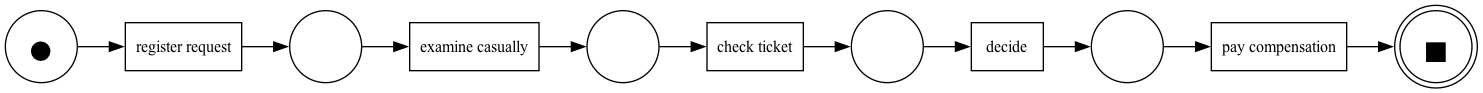

In [3]:
print("Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:")
trace_viz = pn_visualizer.apply(trace_net, trace_im, trace_fm)
pn_visualizer.view(trace_viz)

Vizualizing the process model 'input petri net':


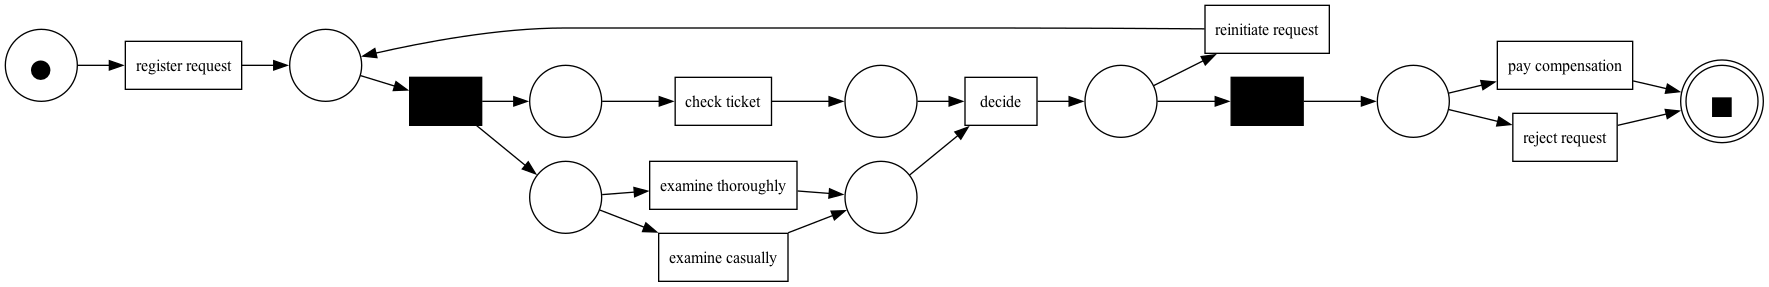

In [4]:
print("Vizualizing the process model 'input petri net':")
process_model_viz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(process_model_viz)

Viszalizing the constructed Synchronous Product Net (SPN):


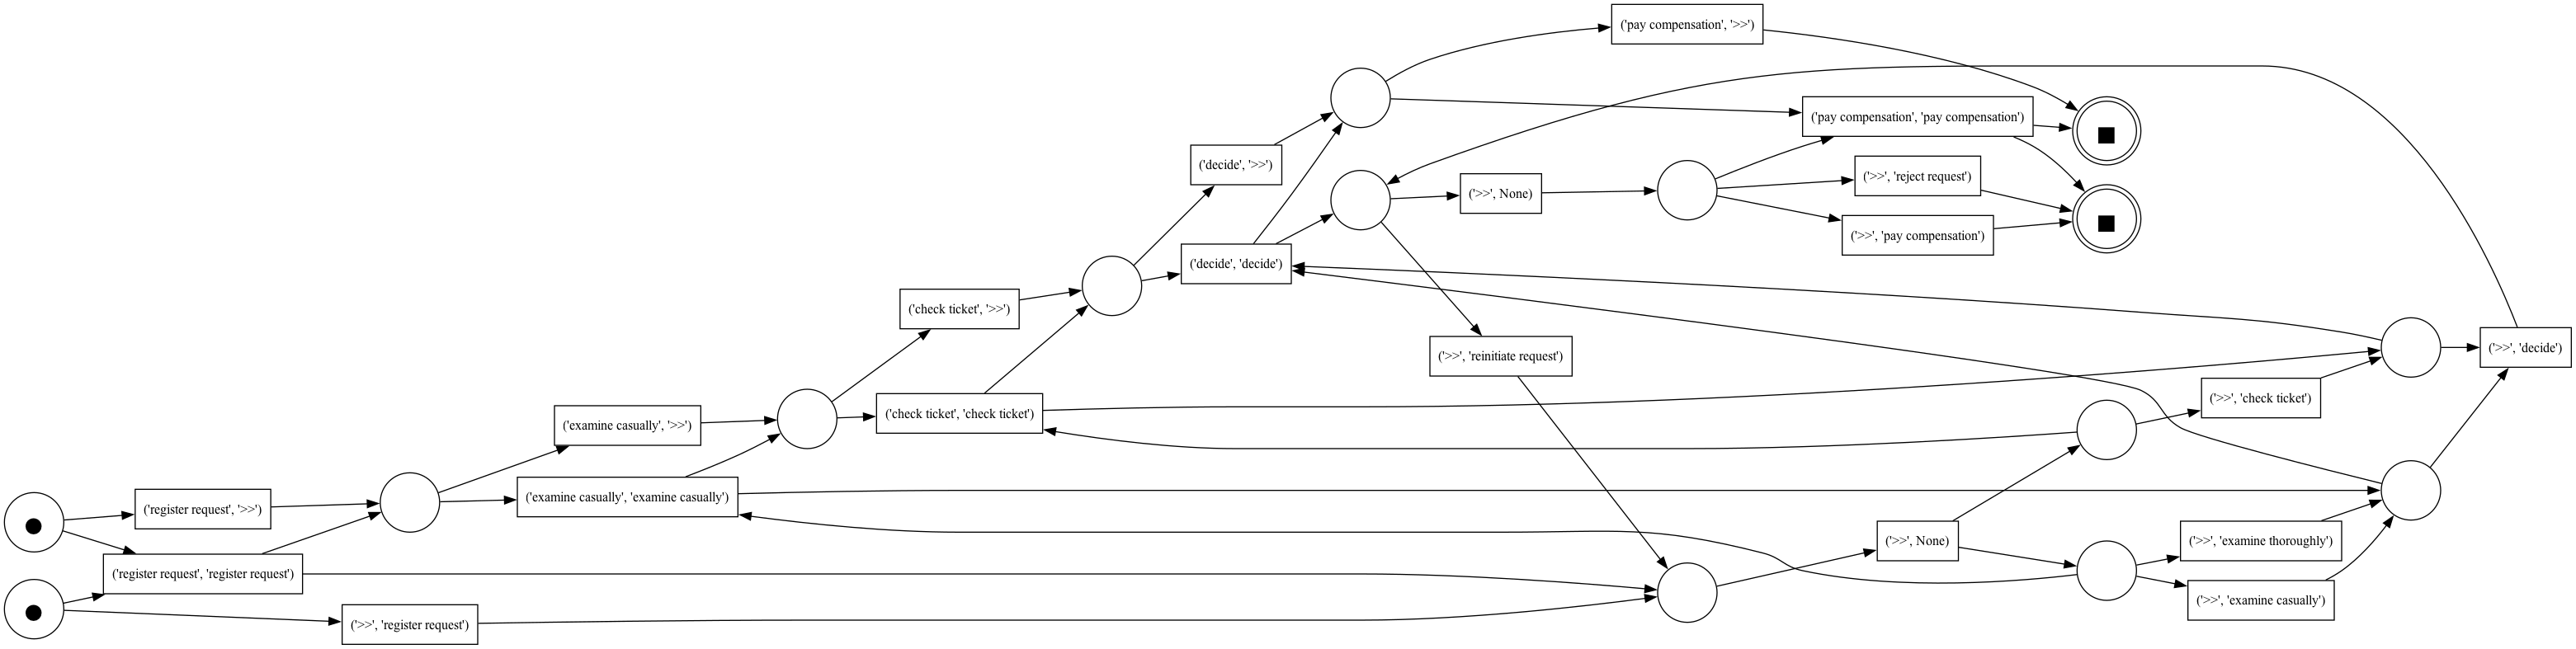

In [5]:
print("Viszalizing the constructed Synchronous Product Net (SPN):")
gviz = pn_visualizer.apply(sync_prod, sync_initial_marking, sync_final_marking)
pn_visualizer.view(gviz)



In [6]:
# save the SPN
#pn_visualizer.save(gviz, "./synchronous_product_net.png")

In [21]:
# %% [code] {"id":"a9f09f7153e2f162"}
if 'sync_prod' in locals():
    # --- Build the components for the State (Marking) Equation LP ---
    # The state equation is: m_f = m_i + A * x  (where A is the incidence matrix)
    # For the LP solver, we rearrange it to: A * x = m_f - m_i
    # We want to minimize the total cost: c^T * x

    # 1. Build the Incidence Matrix (A_eq for the solver)
    # This matrix describes how firing each transition changes the token count in each place.
    # Rows correspond to places, columns correspond to transitions.
    # A value of +1 means a token is produced in that place by that transition.
    # A value of -1 means a token is consumed from that place by that transition.
    # A value of 0 means no change.
    # The pm4py .a_matrix is (Transitions x Places), so we transpose it.
    incidence_matrix = inc_mat_construct(sync_prod)
    A_eq = np.array(incidence_matrix.a_matrix).T
    print("--- 1. Incidence Matrix (A_eq) ---")
    print("Represents the net change in tokens for each place (rows) when each transition (columns) fires.")
    print(f"(Shape: {A_eq.shape} = Transitions x Places)")
    print("Matrix A_eq:\n", A_eq) # Uncomment to see the full matrix

    # 2. Build the initial/final marking vectors (m_i, m_f) and the difference vector (b_eq)
    # These functions create vectors representing token counts in each place for the
    # initial and final markings of the Synchronous Product Net (SPN).
    ini_vec, fin_vec, cost_vec = align_utils.__vectorize_initial_final_cost(
        incidence_matrix, sync_initial_marking, sync_final_marking, cost_function
    )
    ini_vec = np.array(ini_vec)
    fin_vec = np.array(fin_vec)
    cost_vec = np.array(cost_vec) # We'll handle this cost vector in step 3

    print("\n--- 2. Marking Vectors ---")
    print("Initial Marking Vector (m_i): Represents the token count in each place at the start.")
    print(f"(Shape: {ini_vec.shape})")
    print("Vector m_i:\n", ini_vec)
    print("\nFinal Marking Vector (m_f): Represents the target token count in each place.")
    print(f"(Shape: {fin_vec.shape})")
    print("Vector m_f:\n", fin_vec)

    # b_eq = m_f - m_i
    # This vector represents the required *net change* in token counts for each place
    # to get from the initial marking to the final marking.
    b_eq = fin_vec - ini_vec
    print("\nDifference Vector (b_eq = m_f - m_i): Represents the required net token change per place.")
    print(f"(Shape: {b_eq.shape})")
    print("Vector b_eq:\n", b_eq)

    # 3. Get the cost vector (c)
    # This vector represents the cost associated with firing each transition *once*.
    # Synchronous moves typically have cost 0 (or epsilon).
    # Log and Model moves typically have cost 1.
    # Silent (tau) model moves have cost 0.
    # The LP solver wants this as a 1D array or column vector.
    c = np.array(cost_vec, dtype=np.float64) # Ensure float type for solver
    print("\n--- 3. Cost Vector (c) ---")
    print("Represents the cost of firing each transition (columns of A_eq) once.")
    print(f"(Shape: {c.shape})")
    print("Vector c:\n", c)


    # --- Summary of the LP Problem ---
    # We are solving: minimize c^T * x
    # Subject to:      A_eq * x = b_eq
    # Where:
    #   x = vector of firing counts for each transition (the variables the LP solver finds)
    #   c = cost vector (cost per transition firing)
    #   A_eq = incidence matrix (token change per transition per place)
    #   b_eq = required net change in tokens (final marking - initial marking)

    print("\n--- LP Problem Formulation ---")
    print("Minimize: c^T * x  (Total cost of the firing sequence)")
    print("Subject to: A_eq * x = b_eq (The net effect of firings must achieve the target marking difference)")
    print(f"\nVariables (x) shape: ({c.shape[0]},)") # Should match number of transitions
    print(f"Equations shape: A_eq({A_eq.shape}) * x({c.shape[0]},) = b_eq({b_eq.shape})")

    print(f"\nThis means our LP problem has:")
    print(f"  {c.shape[0]} variables (x_t for each transition t in the SPN)")
    print(f"  {A_eq.shape[0]} linear equality constraints (one for each place p in the SPN)")

--- 1. Incidence Matrix (A_eq) ---
Represents the net change in tokens for each place (rows) when each transition (columns) fires.
(Shape: (20, 15) = Transitions x Places)
Matrix A_eq:
 [[-1  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 -1  0  0  1  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 -1  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 -1  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 -1  1  0  0  0  0  0  0]
 [ 0  0  0  0  1  0 -1  0 -1  0  0  0  0  0  0]
 [ 0  0  1  0 -1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1 -1  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0 -1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0 -1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 -1  1  0  0]
 [ 0  0  0  0  0 -1  1  0  0  0  0 -1  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 -1  1  0]
 [ 0  0  0  0  1  0 -1  0 -1  0  0  0 -1  1  0]
 [ 0  0  0  0  0  0  0  0  0  0 -1  1  0  0  0]
 [ 0  0  0  0  0  0  0 -1  1  0 -1  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 -1  1

In [22]:
consumption_matrix = cons_mat_construct(sync_prod)
consumption_mat = np.array(consumption_matrix.c_matrix).T
print("--- 1. Consumption Matrix of the petri net ---")
print("Describes only the tokens consumed by transitions (the input arcs). This is different from the incidence matrix $C$, which describes the net change (output - input).")
print(f"(Shape: {consumption_mat.shape} = Transitions x Places)")
print("Consumption Matrix:\n", consumption_mat)

--- 1. Consumption Matrix of the petri net ---
Describes only the tokens consumed by transitions (the input arcs). This is different from the incidence matrix $C$, which describes the net change (output - input).
(Shape: (20, 15) = Transitions x Places)
Consumption Matrix:
 [[-1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 -1  0 -1  0  0  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0 -1  0  0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0]
 [ 0  0  0  0  0  0 -1  0 -1  0  0  0 -1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0]
 [ 0 

In [7]:
# Run the candidate comparison and print more detailed logs
import time, os
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments_algorithm
from pm4py.pm4py.algo.conformance.alignments.petri_net.algorithm import Variants as AlignmentsVariants
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.petri_net.importer import importer as petri_importer
log_path = os.path.join('pm4py', 'tests', 'input_data', 'running-example.xes')
pnml_path = os.path.join('pm4py', 'tests', 'input_data', 'running-example.pnml')
log = xes_importer.apply(log_path)
net, im, fm = petri_importer.apply(pnml_path)
trace = log[0]
candidates = {
    "1. Dijkstra (h=0)": AlignmentsVariants.VERSION_DIJKSTRA_LESS_MEMORY,
    "2. LP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR,
    "3. ILP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR_ILP,
    "4. Incremental A*": AlignmentsVariants.VERSION_INCREMENTAL_A_STAR,
}

for name, variant in candidates.items():
    print('\nTesting Candidate:', name)
    start_time = time.time()
    res = alignments_algorithm.apply_trace(trace, net, im, fm, parameters=None, variant=variant)
    end_time = time.time()
    if res:
        print(' SUCCESS:\n cost=', res['cost'], ' lp_solved=', res.get('lp_solved'))
        print(' Alignment length=', len(res['alignment']))
        print(' Visited states=', res['visited_states'])
        print(' Time (ms):', (end_time-start_time)*1000)
    else:
        print(' Returned None')
        print(' Time (ms):', (end_time-start_time)*1000)


parsing log, completed traces :: 100%|██████████| 6/6 [00:00<00:00, 4096.00it/s]


Testing Candidate: 1. Dijkstra (h=0)
 SUCCESS:
 cost= 1  lp_solved= None
 Alignment length= 12
 Visited states= 13
 Time (ms): 0.5888938903808594

Testing Candidate: 2. LP-Heuristic
 SUCCESS:
 cost= 3  lp_solved= 1
 Alignment length= 12
 Visited states= 13
 Time (ms): 7.483005523681641

Testing Candidate: 3. ILP-Heuristic
 SUCCESS:
 cost= 3  lp_solved= 1
 Alignment length= 12
 Visited states= 13
 Time (ms): 1.3811588287353516

Testing Candidate: 4. Incremental A*
 SUCCESS:
 cost= 3  lp_solved= 1
 Alignment length= 12
 Visited states= 13
 Time (ms): 11.722087860107422
